IoU - Average: 0.77, Median: 0.92
Hausdorff_Distance - Average: 260.44, Median: 47.32
Symmetric_Difference_Area - Average: 176214.64, Median: 33601.89
Centroid_Distance - Average: 103.85, Median: 11.03


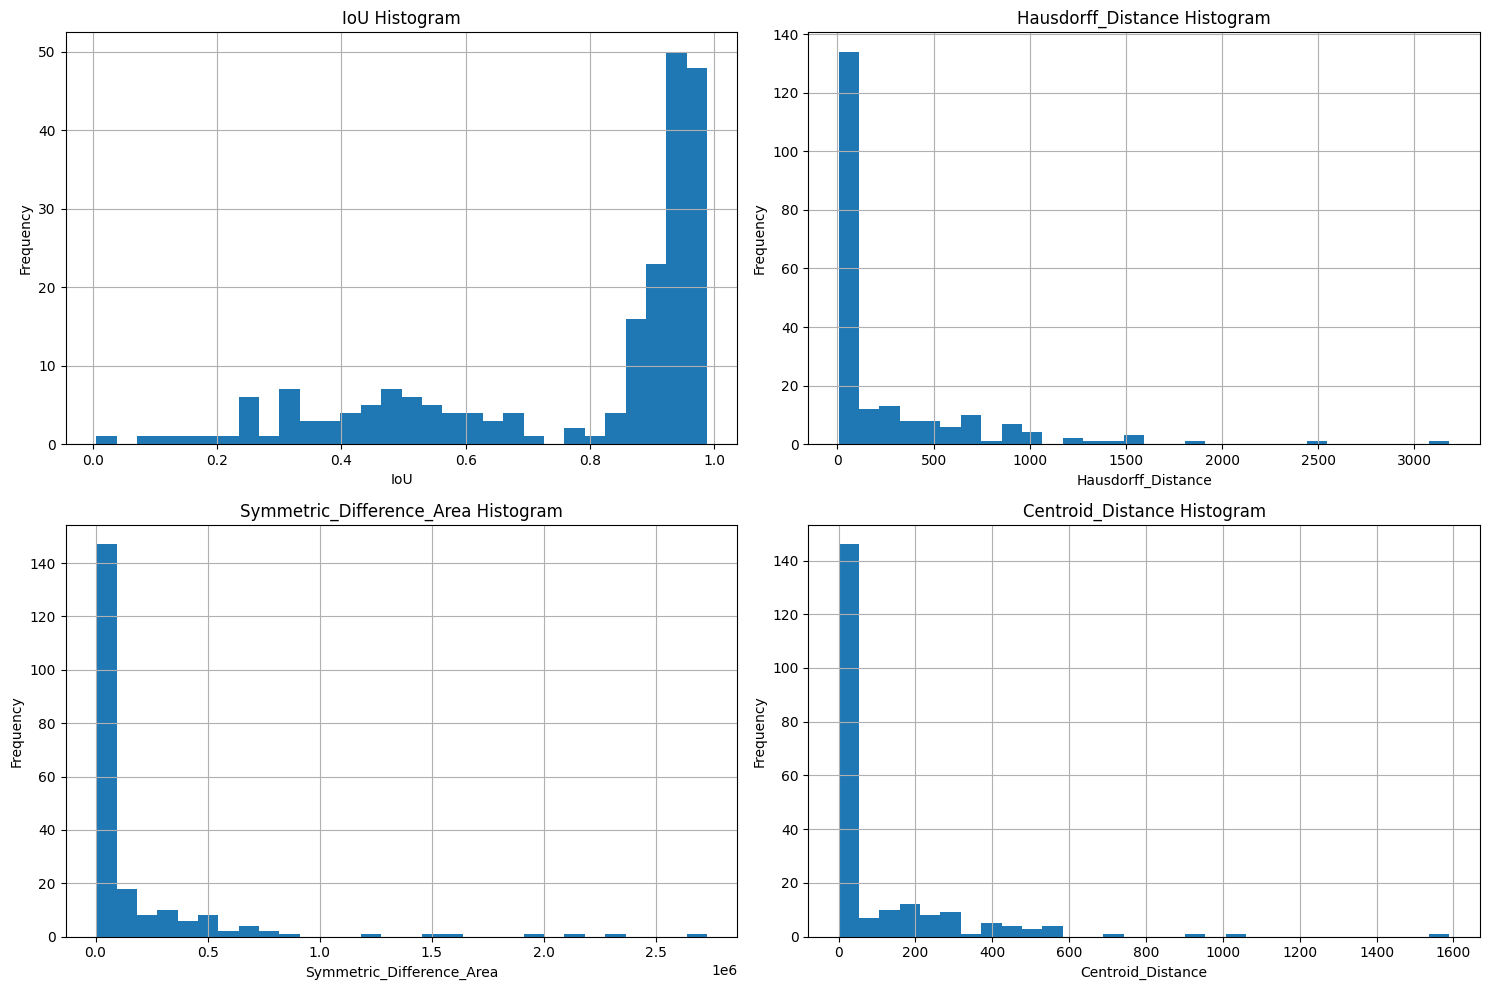

In [7]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

# Load the shapefiles
gdf1 = gpd.read_file(r"C:\Users\grupp\Downloads\MG_Fields_jupiter\MG_Fields.shp")
gdf2 = gpd.read_file(r"C:\Users\grupp\Downloads\MG_Fields_Hunter_Blevins\HMB_Calibration_Annotations.shp")
#gdf1 = gpd.read_file(r"C:\Users\grupp\Downloads\Mato Grosso - Labeler vs Labeler - TG labels-20250327T154921Z-001\Mato Grosso - Labeler vs Labeler - TG labels\matogrossoTG2020labels.shp")

# Ensure both GeoDataFrames use the same coordinate reference system
gdf1 = gdf1.to_crs(gdf2.crs)

# Function to calculate Intersection over Union (IoU)
def calculate_iou(poly1, poly2):
    intersection = poly1.intersection(poly2).area
    union = poly1.union(poly2).area
    return intersection / union

# Function to calculate Hausdorff distance
def calculate_hausdorff_distance(poly1, poly2):
    return poly1.hausdorff_distance(poly2)

# Function to calculate Symmetric Difference Area
def calculate_symmetric_difference_area(poly1, poly2):
    symmetric_difference = poly1.symmetric_difference(poly2).area
    return symmetric_difference

# Find the pair with the highest IoU for each polygon in gdf1
results = []
for idx1, row1 in gdf1.iterrows():
    best_match = {"IoU": 0}
    for idx2, row2 in gdf2.iterrows():
        if row1.geometry.intersects(row2.geometry):
            iou = calculate_iou(row1.geometry, row2.geometry)
            if iou > best_match["IoU"]:
                best_match = {
                    "Index1": idx1,
                    "Index2": idx2,
                    "IoU": iou,
                    "Hausdorff_Distance": calculate_hausdorff_distance(row1.geometry, row2.geometry),
                    "Symmetric_Difference_Area": calculate_symmetric_difference_area(row1.geometry, row2.geometry),
                    "Centroid_Distance": row1.geometry.centroid.distance(row2.geometry.centroid)
                }
    if best_match["IoU"] > 0:
        results.append(best_match)

# Convert results to DataFrame for better visualization and further analysis
results_df = gpd.GeoDataFrame(results)

# Calculate the average and median of each metric
metrics_stats = {}
for metric in ['IoU', 'Hausdorff_Distance', 'Symmetric_Difference_Area', 'Centroid_Distance']:
    average_value = results_df[metric].mean()
    median_value = results_df[metric].median()
    metrics_stats[metric] = (average_value, median_value)

# Print average and median for each metric
for metric, stats in metrics_stats.items():
    print(f"{metric} - Average: {stats[0]:.2f}, Median: {stats[1]:.2f}")

# Plot histograms for each metric
fig, axs = plt.subplots(2, 2, figsize=(15, 10))
for ax, metric in zip(axs.flatten(), ['IoU', 'Hausdorff_Distance', 'Symmetric_Difference_Area', 'Centroid_Distance']):
    results_df[metric].hist(bins=30, ax=ax)
    ax.set_title(f'{metric} Histogram')
    ax.set_xlabel(metric)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()


IoU - Average: 0.71, Median: 0.88
Hausdorff_Distance - Average: 289.47, Median: 58.74
Symmetric_Difference_Area - Average: 196137.50, Median: 41939.06
Centroid_Distance - Average: 120.11, Median: 14.39
Orientation_Difference - Average: 3.61, Median: 0.69
Boundary_Length_Ratio - Average: 0.96, Median: 1.00


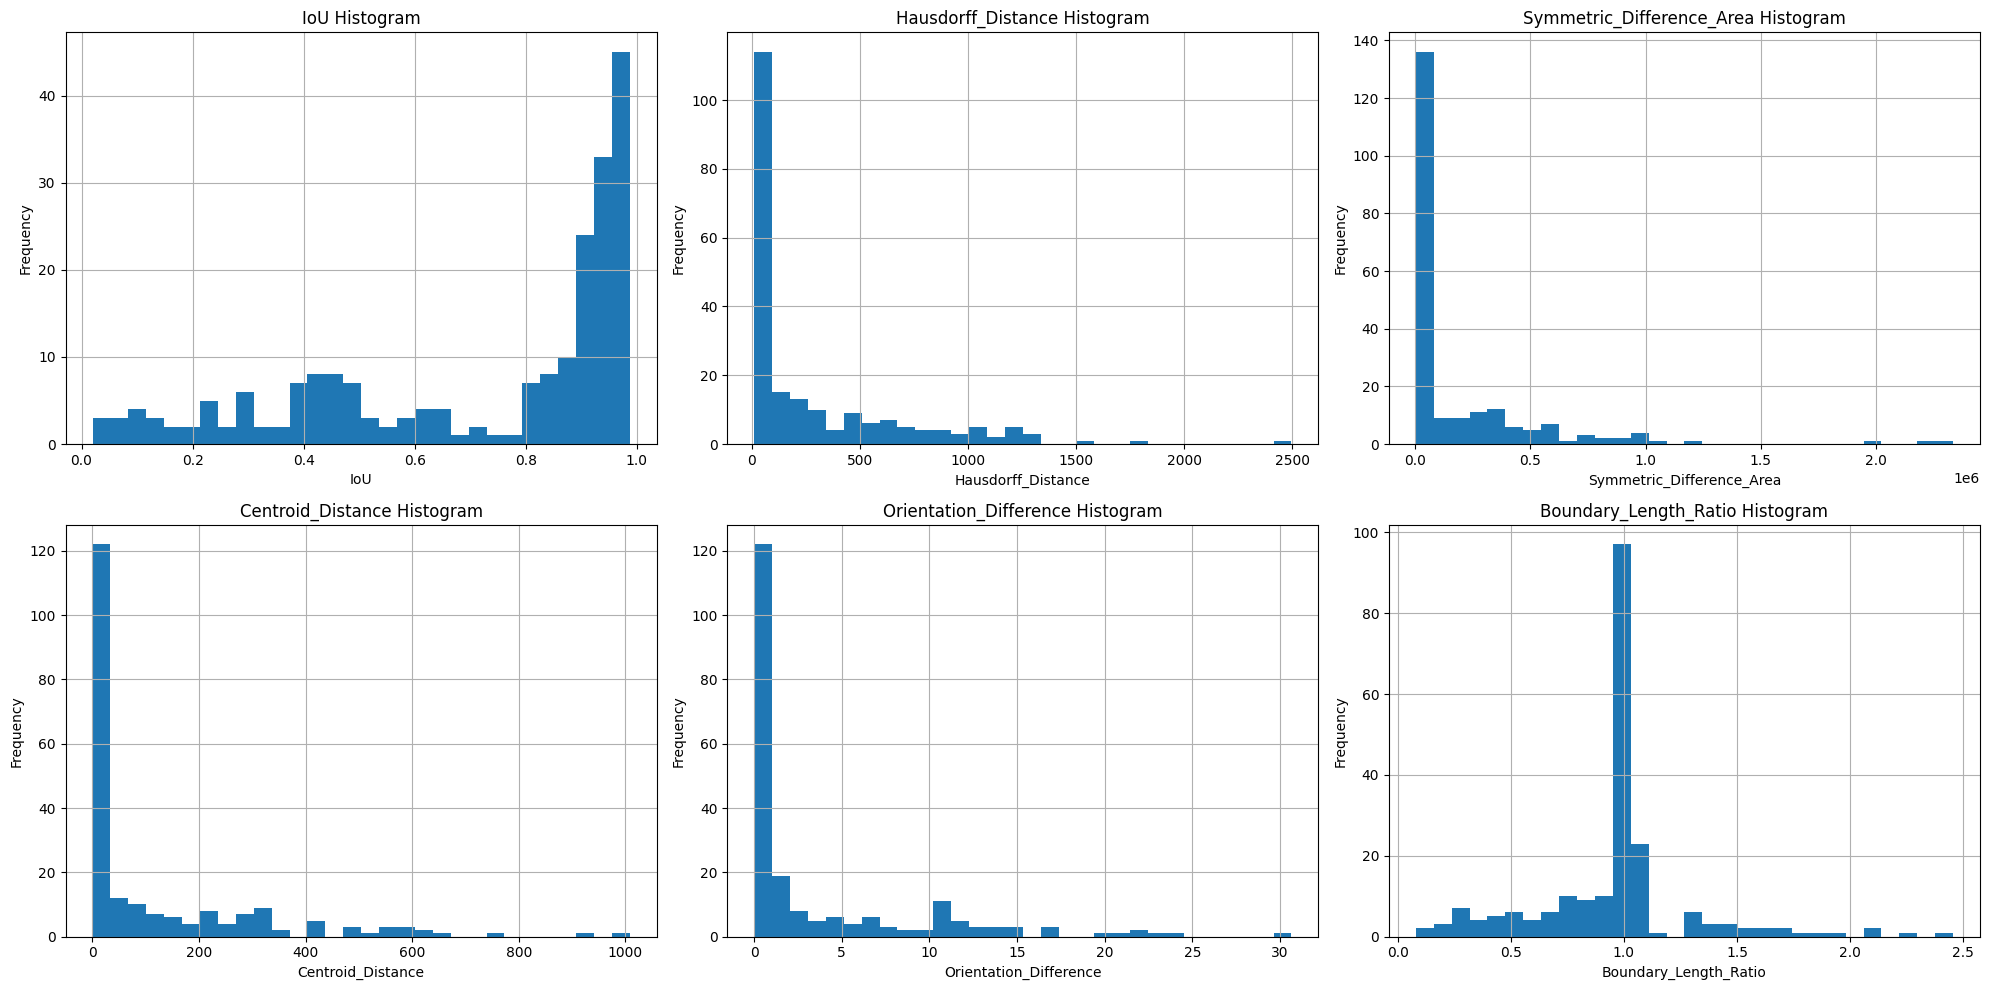

In [3]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.affinity import rotate

# Load the shapefiles
#gdf1 = gpd.read_file(r"C:\Users\grupp\Downloads\MG_Fields_jupiter\MG_Fields.shp")
gdf2 = gpd.read_file(r"C:\Users\grupp\Downloads\MG_Fields_Hunter_Blevins\HMB_Calibration_Annotations.shp")
gdf1 = gpd.read_file(r"C:\Users\grupp\Downloads\Mato Grosso - Labeler vs Labeler - TG labels-20250327T154921Z-001\Mato Grosso - Labeler vs Labeler - TG labels\matogrossoTG2020labels.shp")

# Ensure both GeoDataFrames use the same coordinate reference system
gdf1 = gdf1.to_crs(gdf2.crs)

# Function to calculate Orientation Difference
def calculate_orientation_difference(poly1, poly2):
    rect1 = poly1.minimum_rotated_rectangle
    rect2 = poly2.minimum_rotated_rectangle
    angle1 = np.degrees(np.arctan2(rect1.bounds[3] - rect1.bounds[1], rect1.bounds[2] - rect1.bounds[0]))
    angle2 = np.degrees(np.arctan2(rect2.bounds[3] - rect2.bounds[1], rect2.bounds[2] - rect2.bounds[0]))
    return abs(angle1 - angle2)

# Function to calculate Boundary Length Ratio
def calculate_boundary_length_ratio(poly1, poly2):
    length1 = poly1.boundary.length
    length2 = poly2.boundary.length
    return length1 / length2 if length2 != 0 else np.inf

# Update results processing to include new metrics
results = []
for idx1, row1 in gdf1.iterrows():
    best_match = {"IoU": 0}
    for idx2, row2 in gdf2.iterrows():
        if row1.geometry.intersects(row2.geometry):
            iou = calculate_iou(row1.geometry, row2.geometry)
            if iou > best_match["IoU"]:
                orientation_diff = calculate_orientation_difference(row1.geometry, row2.geometry)
                boundary_length_ratio = calculate_boundary_length_ratio(row1.geometry, row2.geometry)
                best_match = {
                    "Index1": idx1,
                    "Index2": idx2,
                    "IoU": iou,
                    "Hausdorff_Distance": calculate_hausdorff_distance(row1.geometry, row2.geometry),
                    "Symmetric_Difference_Area": calculate_symmetric_difference_area(row1.geometry, row2.geometry),
                    "Centroid_Distance": row1.geometry.centroid.distance(row2.geometry.centroid),
                    "Orientation_Difference": orientation_diff,
                    "Boundary_Length_Ratio": boundary_length_ratio
                }
    if best_match["IoU"] > 0:
        results.append(best_match)

# Convert results to DataFrame for better visualization and further analysis
results_df = gpd.GeoDataFrame(results)

# Calculate and print statistics
metrics_stats = {}
for metric in results_df.columns[2:]:
    average_value = results_df[metric].mean()
    median_value = results_df[metric].median()
    metrics_stats[metric] = (average_value, median_value)

for metric, stats in metrics_stats.items():
    print(f"{metric} - Average: {stats[0]:.2f}, Median: {stats[1]:.2f}")

# Plot histograms for each metric
fig, axs = plt.subplots(2, 3, figsize=(20, 10))
for ax, metric in zip(axs.flatten(), results_df.columns[2:]):
    results_df[metric].hist(bins=30, ax=ax)
    ax.set_title(f'{metric} Histogram')
    ax.set_xlabel(metric)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()


In [4]:
# Function to calculate the difference in number of vertices
def calculate_vertices_difference(poly1, poly2):
    return abs(len(poly1.exterior.coords) - len(poly2.exterior.coords))

# Collect the vertices differences for each best match
vertices_differences = []
for result in results:
    idx1 = result["Index1"]
    idx2 = result["Index2"]
    poly1 = gdf1.iloc[idx1].geometry
    poly2 = gdf2.iloc[idx2].geometry
    vertices_difference = calculate_vertices_difference(poly1, poly2)
    vertices_differences.append(vertices_difference)

# Calculate and print the average difference in number of vertices
if vertices_differences:
    average_vertices_difference = np.mean(vertices_differences)
    print(f"Average Difference in Number of Vertices: {average_vertices_difference:.2f}")
else:
    print("No overlapping polygons to compare.")


Average Difference in Number of Vertices: 13.36
